In [6]:
import mat73
import os
import numpy as np
import xarray as xr
import globals as gl
from lfp import make_freq_masks
import matplotlib.pyplot as plt
plt.style.use('default')

In [11]:
cfg = mat73.loadmat(os.path.join(gl.nhpDir, gl.lfpDir,'Malfoy/cfg.PMd-19.mat'))['cfg']
foi = cfg['foi']
freq_masks = make_freq_masks(cfg)

t_cue = np.linspace(0, gl.cuePost - 1, gl.cuePost)
t_pert = np.linspace(gl.pertPre, gl.pertPost - 1, gl.pertPost - gl.pertPre) + 5
t = np.concatenate((t_cue, t_pert))

monkey = ['Malfoy', 'Pert']

rois = ['PMd', 'M1', 'S1']

probs = list(gl.cue_mapping.values())

lfp = {'lfp': [], 'roi': []}
spk = {'spk': [], 'roi': []}
for roi in rois:
    for mon in monkey:
        for rec in gl.recordings[mon][roi]:
            lfp_aligned = np.load(os.path.join(gl.nhpDir, gl.lfpDir, mon, f'lfp_aligned.avg.{roi}-{rec}.npy'))
            spk_aligned = np.load(os.path.join(gl.nhpDir, gl.spkDir, mon, f'spk_aligned.avg.{roi}-{rec}.npy'))
            lfp["lfp"].append(lfp_aligned)
            lfp["roi"].append(roi)
            spk["spk"].append(spk_aligned.mean(axis=-1))
            spk["roi"].append(roi)

lfp = xr.DataArray(data=np.stack(lfp["lfp"]),
                   dims=('roi', 'time', 'freq'),
                   coords={
                       'roi': lfp['roi'],
                       'freq': foi,
                       'time': t,
                       #'prob': np.arange(5),
                       #'channel': np.arange(32)
                   })
spk = xr.DataArray(data=np.stack(spk["spk"]),
                   dims=('roi', 'time', ),
                   coords={
                       'roi': lfp['roi'],
                       'time': t,
                       #'prob': np.arange(5),
                   })

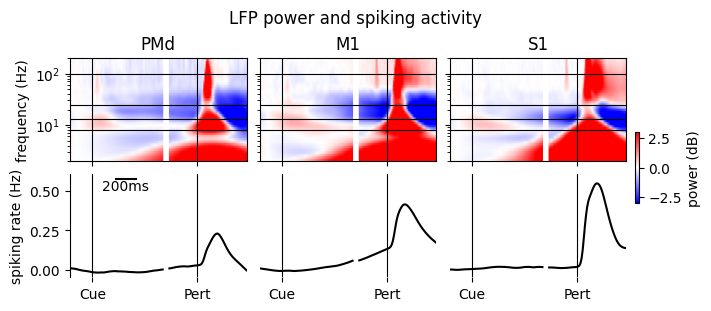

In [53]:
fig, axs = plt.subplots(2, len(rois), sharex='col', sharey='row', figsize=(7, 3), constrained_layout=True)

vmin, vmax = -3, 3

bs_lfp = lfp.sel(time=slice(0, gl.cueIdx-5)).mean(axis=1)
bs_spk = spk.sel(time=slice(0, gl.cueIdx-5)).mean(axis=1)
lfp_dB = (10 * np.log10(lfp / bs_lfp))
spk = spk - bs_spk

for r, roi in enumerate(rois):
    ax = axs[:, r]
    ax[0].set_yscale('log')
    lfp_cue = lfp_dB.sel(roi=roi, time=slice(0, gl.cuePost-1)).mean(axis=0)
    lfp_pert = lfp_dB.sel(roi=roi, time=slice(gl.pertPre, None)).mean(axis=0)
    h = ax[0].pcolormesh(t_cue, foi, lfp_cue.T, vmin=vmin, vmax=vmax, cmap='bwr', shading='gouraud')
    ax[0].pcolormesh(t_pert, foi, lfp_pert.T, vmin=vmin, vmax=vmax, cmap='bwr',shading='gouraud')
    ax[0].axhline(8, color='k', lw='.8')
    ax[0].axhline(13, color='k', lw='.8')
    ax[0].axhline(25, color='k', lw='.8')
    ax[0].axhline(100, color='k', lw='.8')
    ax[0].axvline(gl.cueIdx, color='k', lw='.8')
    ax[0].axvline(gl.pertIdx, color='k', lw='.8')
    ax[0].set_xticks([gl.cueIdx, gl.pertIdx])
    ax[0].set_xticklabels(['Cue', 'Pert'])
    ax[0].set_title(roi)
    spk_cue = spk.sel(roi=roi, time=slice(0, gl.cuePost-1)).mean(axis=0)
    spk_pert = spk.sel(roi=roi, time=slice(gl.pertPre, None)).mean(axis=0)
    ax[1].plot(t_cue, spk_cue, color='k')
    ax[1].plot(t_pert, spk_pert, color='k')
    ax[1].spines[['right', 'top', 'bottom']].set_visible(False)
    ax[1].axvline(gl.cueIdx, color='k', lw='.8')
    ax[1].axvline(gl.pertIdx, color='k', lw='.8')
    ax[1].spines['left'].set_visible(False) if r>0 else None
    ax[1].tick_params(left=False) if r>0 else None

yline = axs[1, 0].get_ylim()[1]
axs[1, 0].hlines(yline, gl.cueIdx + 20, gl.cueIdx + 40, color='k',)
axs[1, 0].text(gl.cueIdx + 30, yline, '200ms',  va='top', ha='center')

fig.colorbar(h, ax=ax, label='power (dB)', fraction=0.02)
axs[0, 0].set_ylabel('frequency (Hz)')
axs[1, 0].set_ylabel('spiking rate (Hz)')
fig.suptitle('LFP power and spiking activity')

plt.show()